##### Fake Review Detection - Exploratory Data Analysis (EDA)
To Understand the dataset structure, distribution, and patterns before building the ML models.
##### Dataset
Yelp Fake Review Dataset downloaded from Kaggle
##### Key Columns
- reviewContent → input text
- flagged → target label (0 = real, 1 = fake)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train_df = pd.read_csv('../../data/train.csv', sep='\t')
train_df = train_df.drop(columns=['Unnamed: 0'])

train_df.head()

,reviewID,reviewerID,restaurantID,date,rating,reviewUsefulCount,reviewContent,flagged,name,location,...,reviewCount,firstCount,usefulCount,coolCount,funnyCount,complimentCount,tipCount,fanCount,restaurantRating,ReviewLength
0,Z_wgGcI8_Txo87Wz7CxdrQ,cM9GIlk61Qh2thLyJyxNyA,N7juvW8YoFIj7sEBzVF8GQ,9/17/2010,5,0,as new resident chicago los angeles i mission ...,1,suzie n.,"Los Angeles, CA",...,1,0,1,2,0,0,0,0,4.0,144
1,NJfQb03MSstqYagt860Oaw,SVlSPBnjCzY2Bu9n8y2C5A,o54U2VkQama8FI30qDkWvw,1/31/2008,5,0,great place rarely wait fairly easy find parki...,0,Jacqui B.,"Kalamazoo, MI",...,12,2,19,7,6,4,0,0,4.0,46
2,2uao3bK9iSV4fuMwuSYCiQ,5HYWhPS3ozYifieW0lWMUw,1QKqtC4vML3QhkrSzwR_tQ,3/31/2010,5,0,back bar makes feel though transported china s...,1,Mike A.,"Los Angeles, CA",...,6,0,7,3,2,0,0,0,3.5,18
3,6mVU2JfeSbQ-5RnPm-K6eA,dgKmhiTypR34XNPrMtQyMA,4wreIFjaPMppyEnzKHbozg,4/26/2010,5,0,hands one favorite tourist restaurants city th...,0,Jen K.,"Chicago, IL",...,37,2,16,3,3,1,0,1,3.5,41
4,e25NUAMnVf7-t8-vBO_drA,uB3n74XHDFUKwHxfK5lDvA,N7juvW8YoFIj7sEBzVF8GQ,9/7/2010,5,0,service impeccable staff helpful owner works h...,1,Joe K.,"Barrington, IL",...,3,0,2,1,0,0,0,0,4.0,40


In [5]:
print("Shape:", train_df.shape)
print("\nColumns:\n", train_df.columns)

train_df.info()

Shape: (9929, 22)

Columns:
 Index(['reviewID', 'reviewerID', 'restaurantID', 'date', 'rating',
       'reviewUsefulCount', 'reviewContent', 'flagged', 'name', 'location',
       'yelpJoinDate', 'friendCount', 'reviewCount', 'firstCount',
       'usefulCount', 'coolCount', 'funnyCount', 'complimentCount', 'tipCount',
       'fanCount', 'restaurantRating', 'ReviewLength'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 9929 entries, 0 to 9928
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   reviewID           9929 non-null   str    
 1   reviewerID         9929 non-null   str    
 2   restaurantID       9929 non-null   str    
 3   date               9929 non-null   str    
 4   rating             9929 non-null   int64  
 5   reviewUsefulCount  9929 non-null   int64  
 6   reviewContent      9926 non-null   str    
 7   flagged            9929 non-null   int64  
 8   name               9929 n

In [6]:
train_df = train_df.dropna(subset=['reviewContent'])

In [7]:
train_df['flagged'].value_counts()

flagged
0    4993
1    4933
Name: count, dtype: int64

In [8]:
train_df.groupby('flagged')['ReviewLength'].mean()

flagged
0    89.305628
1    61.110886
Name: ReviewLength, dtype: float64

In [ ]:
#We observed that fake reviews tend to be shorter than genuine ones, indicating lower effort and lack of detail. This feature was useful as a behavioral signal in our model.

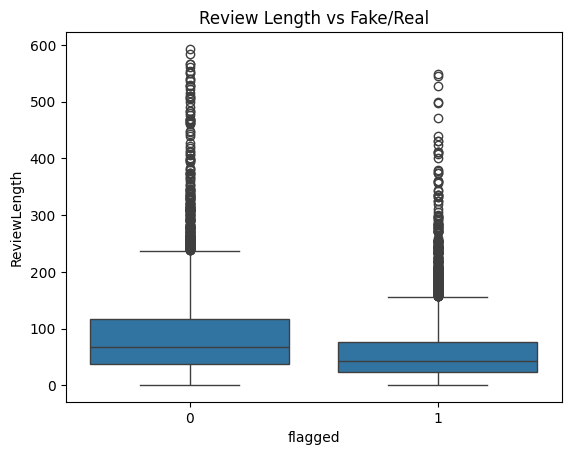

In [ ]:
sns.boxplot(x='flagged', y='ReviewLength', data=train_df)
plt.title("Review Length vs Fake/Real")
plt.show()

In [12]:
train_df.groupby('flagged')['rating'].mean()

flagged
0    3.968756
1    3.816339
Name: rating, dtype: float64

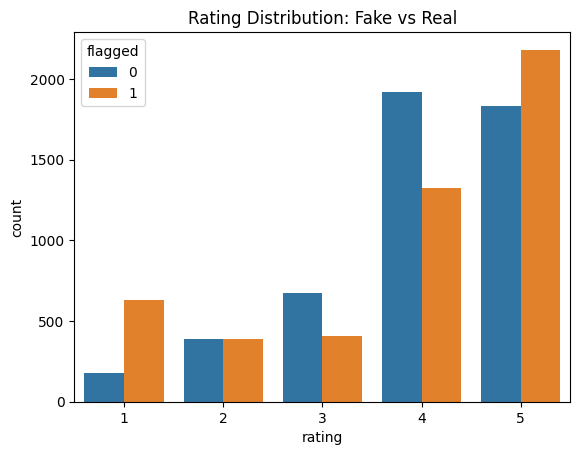

In [13]:
sns.countplot(x='rating', hue='flagged', data=train_df)
plt.title("Rating Distribution: Fake vs Real")
plt.show()

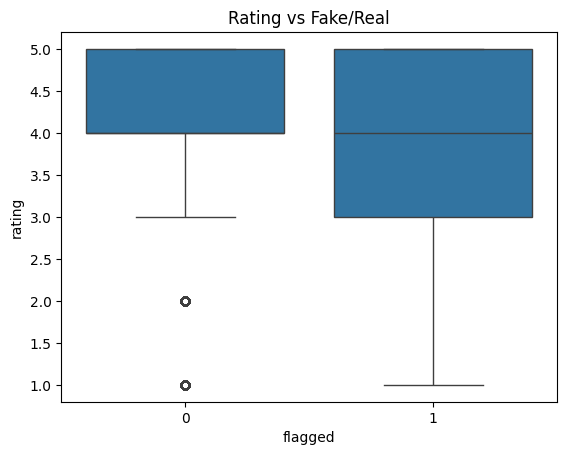

In [10]:
sns.boxplot(x='flagged', y='rating', data=train_df)
plt.title("Rating vs Fake/Real")
plt.show()

In [14]:
train_df.groupby('flagged')['reviewCount'].mean()

flagged
0    122.298218
1      7.136428
Name: reviewCount, dtype: float64

In [15]:
'''Fake reviewers are:
1)new / low-activity users
2)not established accounts
Real reviewers are:
1)highly active users
2)experienced on platform'''

'Fake reviewers are:\n1)new / low-activity users\n2)not established accounts\nReal reviewers are:\n1)highly active users\n2)experienced on platform'

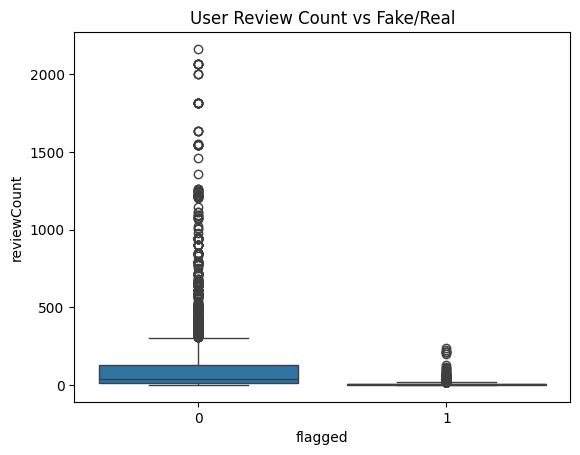

In [11]:
sns.boxplot(x='flagged', y='reviewCount', data=train_df)
plt.title("User Review Count vs Fake/Real")
plt.show()

In [17]:
'''We found that fake reviews are often posted by low-activity users, 
with an average review count of ~7 compared to ~122 for genuine users. 
This strong behavioral signal significantly improves 
detection performance.'''

'We found that fake reviews are often posted by low-activity users, \nwith an average review count of ~7 compared to ~122 for genuine users. \nThis strong behavioral signal significantly improves \ndetection performance.'